In [15]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

import cv2
import numpy as np
import mediapipe as mp
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
import matplotlib.pyplot as plt

In [16]:
# ==========================================
# PREPROCESSING (CLAHE)
# ==========================================

# Fungsi Preprocessing CLAHE (Peningkatan Kontras)
def apply_clahe(img):
    """Meningkatkan kontras gambar menggunakan CLAHE agar
    MediaPipe lebih akurat mendeteksi titik wajah,
    terutama pada kondisi pencahayaan buruk."""
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    l = clahe.apply(l)
    enhanced = cv2.merge((l, a, b))
    return cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

print("[INFO] Fungsi Preprocessing CLAHE berhasil didefinisikan.")
print("  - Metode  : CLAHE (Contrast Limited Adaptive Histogram Equalization)")
print("  - clipLimit   : 2.0")
print("  - tileGridSize: (8, 8)")


[INFO] Fungsi Preprocessing CLAHE berhasil didefinisikan.
  - Metode  : CLAHE (Contrast Limited Adaptive Histogram Equalization)
  - clipLimit   : 2.0
  - tileGridSize: (8, 8)


In [17]:
import os
os.environ['PROTOCOL_BUFFERS_PYTHON_IMPLEMENTATION'] = 'python'

# ==========================================
# EKSTRAKSI FITUR GEOMETRIS MEDIAPIPE
# ==========================================
import cv2
import numpy as np
import mediapipe as mp

# Inisialisasi MediaPipe Face Mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5
)

dataset_path = "Dataset/Dataset_wajah"
X = []
Y = []
gagal_deteksi = 0

print("[INFO] Memulai Preprocessing CLAHE + Ekstraksi Fitur MediaPipe...")
print()

for person_name in os.listdir(dataset_path):
    person_dir = os.path.join(dataset_path, person_name)
    if not os.path.isdir(person_dir):
        continue

    count = 0
    for image_name in os.listdir(person_dir):
        image_path = os.path.join(person_dir, image_name)
        img = cv2.imread(image_path)
        if img is None:
            continue

        # TAHAP 1: Preprocessing CLAHE
        img_enhanced = apply_clahe(img)

        # TAHAP 2: Konversi BGR ke RGB
        img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)

        # TAHAP 3: Ekstraksi 468 Titik Wajah MediaPipe
        results = face_mesh.process(img_rgb)

        if results.multi_face_landmarks:
            face_landmarks = results.multi_face_landmarks[0]

            # Kumpulkan koordinat (X, Y, Z) dari ke-468 titik wajah
            landmarks_array = []
            for landmark in face_landmarks.landmark:
                landmarks_array.append([landmark.x, landmark.y, landmark.z])

            X.append(landmarks_array)
            Y.append(person_name)
            count += 1
        else:
            gagal_deteksi += 1

    print(f"  {person_name}: {count} wajah berhasil diekstrak")

# Mengubah ke dalam bentuk NumPy Array
X = np.array(X)  # Bentuk: (jumlah_gambar, 468, 3)
Y = np.array(Y)

# TAHAP 4: Normalisasi Z-Score
# Agar nilai X, Y, Z memiliki skala seragam
mean = X.mean(axis=0)
std = X.std(axis=0) + 1e-8
X = (X - mean) / std

np.save("mean_landmark.npy", mean)
np.save("std_landmark.npy", std)

print()
print("=== HASIL EKSTRAKSI FITUR ===")
print(f"Total wajah berhasil diekstrak  : {len(X)}")
print(f"Total wajah gagal terdeteksi    : {gagal_deteksi}")
print(f"Bentuk (Shape) Data X input CNN : {X.shape}")
print(f"Nilai X setelah normalisasi (contoh 3 titik pertama):")
print(f"  {X[0][:3]}")


[INFO] Memulai Preprocessing CLAHE + Ekstraksi Fitur MediaPipe...



d:\FaceAttend_VC\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


  Faza Humairah: 105 wajah berhasil diekstrak
  Jabbal Akbar: 105 wajah berhasil diekstrak
  Muhammad Alif: 105 wajah berhasil diekstrak
  Muhammad Heikal Fasya: 105 wajah berhasil diekstrak
  Muhammad Rizki Arta Maulana: 105 wajah berhasil diekstrak
  Muhammad Zahrul Ath Thariq: 103 wajah berhasil diekstrak
  Nabila Balqis: 105 wajah berhasil diekstrak
  Natasya Babulrhaiyan: 105 wajah berhasil diekstrak
  Nur Fadhillah Zulfi: 105 wajah berhasil diekstrak
  Putri Al Violy: 105 wajah berhasil diekstrak
  Rahmat Isma Hidayat: 103 wajah berhasil diekstrak
  Riski Maulani: 104 wajah berhasil diekstrak
  Salesya Al Fatila: 105 wajah berhasil diekstrak
  Suci Wildani Rizka: 105 wajah berhasil diekstrak
  Syariqul Husni: 105 wajah berhasil diekstrak
  Syifaurrahman: 105 wajah berhasil diekstrak
  Tasya Anisa: 105 wajah berhasil diekstrak
  Urfi Shanda: 105 wajah berhasil diekstrak
  Vivi Jumilia Hikmah: 105 wajah berhasil diekstrak
  Zuyyin Zafirah: 105 wajah berhasil diekstrak

=== HASIL EK

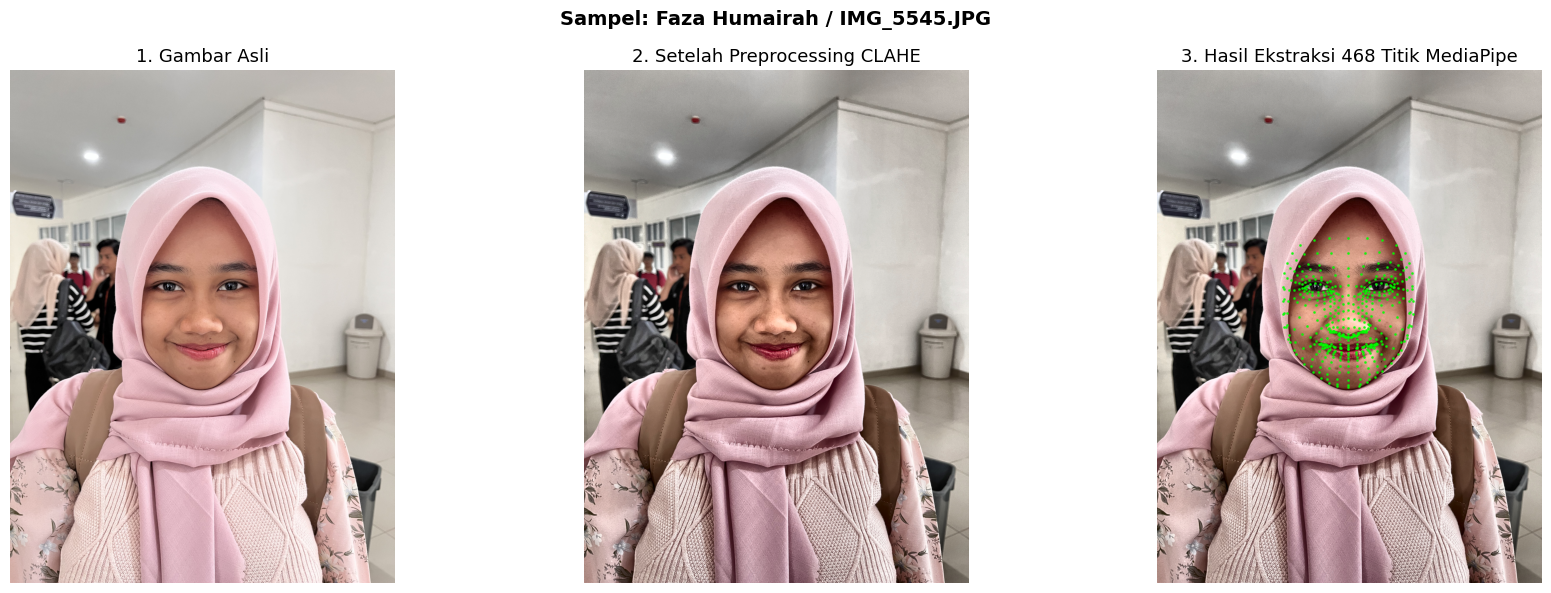

=== DATA NUMERIK MENTAH DARI MEDIAPIPE (5 Titik Pertama) ===
 No |          X |          Y |          Z
------------------------------------------
  0 |   0.496461 |   0.535990 |  -0.028781
  1 |   0.496082 |   0.514681 |  -0.079076
  2 |   0.495802 |   0.520733 |  -0.037741
  3 |   0.482790 |   0.469549 |  -0.066533
  4 |   0.496068 |   0.502078 |  -0.086167
... (dan seterusnya sampai titik ke-467)


In [18]:
# ==========================================
# VISUALISASI HASIL EKSTRAKSI MEDIAPIPE
# ==========================================

import matplotlib.pyplot as plt

# Ambil 1 gambar sampel dari dataset untuk divisualisasikan
sample_person = os.listdir(dataset_path)[0]
sample_dir = os.path.join(dataset_path, sample_person)
sample_img_name = os.listdir(sample_dir)[0]
sample_img_path = os.path.join(sample_dir, sample_img_name)

img_sample = cv2.imread(sample_img_path)
img_enhanced = apply_clahe(img_sample)
img_rgb = cv2.cvtColor(img_enhanced, cv2.COLOR_BGR2RGB)

# Deteksi ulang untuk visualisasi
results_viz = face_mesh.process(img_rgb)

if results_viz.multi_face_landmarks:
    face_lm = results_viz.multi_face_landmarks[0]
    h, w, _ = img_rgb.shape

    # Kumpulkan koordinat piksel dari 468 titik
    xs = [lm.x * w for lm in face_lm.landmark]
    ys = [lm.y * h for lm in face_lm.landmark]

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # --- Gambar 1: Foto Asli ---
    axes[0].imshow(cv2.cvtColor(cv2.imread(sample_img_path), cv2.COLOR_BGR2RGB))
    axes[0].set_title("1. Gambar Asli", fontsize=13)
    axes[0].axis("off")

    # --- Gambar 2: Foto Setelah CLAHE ---
    axes[1].imshow(img_rgb)
    axes[1].set_title("2. Setelah Preprocessing CLAHE", fontsize=13)
    axes[1].axis("off")

    # --- Gambar 3: 468 Titik MediaPipe di Atas Wajah ---
    axes[2].imshow(img_rgb)
    axes[2].scatter(xs, ys, c="lime", s=1, alpha=0.7)
    axes[2].set_title("3. Hasil Ekstraksi 468 Titik MediaPipe", fontsize=13)
    axes[2].axis("off")

    plt.suptitle(f"Sampel: {sample_person} / {sample_img_name}", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    # Tampilkan juga data numerik mentah dari beberapa titik
    print("=== DATA NUMERIK MENTAH DARI MEDIAPIPE (5 Titik Pertama) ===")
    print(f"{'No':>3} | {'X':>10} | {'Y':>10} | {'Z':>10}")
    print("-" * 42)
    for i, lm in enumerate(face_lm.landmark[:5]):
        print(f"{i:>3} | {lm.x:>10.6f} | {lm.y:>10.6f} | {lm.z:>10.6f}")
    print("... (dan seterusnya sampai titik ke-467)")
else:
    print("[WARNING] Wajah tidak terdeteksi pada gambar sampel.")


In [19]:
# Label Encoding (Mengubah nama menjadi angka)
le = LabelEncoder()
Y_encoded = le.fit_transform(Y)
num_classes = len(le.classes_)

# One-Hot Encoding untuk klasifikasi Multikelas
Y_categorical = tf.keras.utils.to_categorical(Y_encoded, num_classes=num_classes)

# Menampilkan hasil Label Encoding
print(" HASIL LABEL ENCODING ")
print(f"Jumlah Kelas/Orang : {num_classes}")
print()
print("Daftar Nama (Label) :")
for idx, name in enumerate(le.classes_):
    print(f"  Index {idx} = {name}")

print()
print("hasil encoding:")
print(f"  Nama asli   : {Y[:20]}")
print(f"  Hasil angka : {Y_encoded[:20]}")

print()
print("One-Hot Encoding")
print(f"  {Y_categorical[20]}")

# Menyimpan Label Encoder ke file pickle
import pickle
with open('label_encoder_last.pickle', 'wb') as f:
    pickle.dump(le, f)
print("[INFO] Label Encoder berhasil disimpan ke 'label_encoder_last.pickle'")


 HASIL LABEL ENCODING 
Jumlah Kelas/Orang : 20

Daftar Nama (Label) :
  Index 0 = Faza Humairah
  Index 1 = Jabbal Akbar
  Index 2 = Muhammad Alif
  Index 3 = Muhammad Heikal Fasya
  Index 4 = Muhammad Rizki Arta Maulana
  Index 5 = Muhammad Zahrul Ath Thariq
  Index 6 = Nabila Balqis
  Index 7 = Natasya Babulrhaiyan
  Index 8 = Nur Fadhillah Zulfi
  Index 9 = Putri Al Violy
  Index 10 = Rahmat Isma Hidayat
  Index 11 = Riski Maulani
  Index 12 = Salesya Al Fatila
  Index 13 = Suci Wildani Rizka
  Index 14 = Syariqul Husni
  Index 15 = Syifaurrahman
  Index 16 = Tasya Anisa
  Index 17 = Urfi Shanda
  Index 18 = Vivi Jumilia Hikmah
  Index 19 = Zuyyin Zafirah

hasil encoding:
  Nama asli   : ['Faza Humairah' 'Faza Humairah' 'Faza Humairah' 'Faza Humairah'
 'Faza Humairah' 'Faza Humairah' 'Faza Humairah' 'Faza Humairah'
 'Faza Humairah' 'Faza Humairah' 'Faza Humairah' 'Faza Humairah'
 'Faza Humairah' 'Faza Humairah' 'Faza Humairah' 'Faza Humairah'
 'Faza Humairah' 'Faza Humairah' 'Faza H

In [20]:
# Memecah data menjadi Data Latih dan Data Uji (80% : 20%)
x_train, x_test, y_train, y_test = train_test_split(X, Y_categorical, test_size=0.2, random_state=42, stratify=Y_categorical)
print(f"Data Latih : {x_train.shape}")
print(f"Data Uji   : {x_test.shape}")
print(f"Jumlah Orang/Kelas : {num_classes}")

Data Latih : (1676, 468, 3)
Data Uji   : (419, 468, 3)
Jumlah Orang/Kelas : 20


In [21]:
# ==========================================
# MEMBANGUN ARSITEKTUR CNN 1 DIMENSI (Conv1D)
# ==========================================
# Catatan: Input model ini adalah (468, 3)
# Artinya: Ada 468 titik wajah berurutan, tiap titik punya 3 fitur (X, Y, Z)

model = Sequential([
    # Layer Konvolusi 1D Pertama
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(468, 3)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Layer Konvolusi 1D Kedua
    Conv1D(128, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Layer Konvolusi 1D Ketiga
    Conv1D(256, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Perataan (Flatten) fitur untuk masuk ke Dense
    Flatten(),
    
    # Lapisan Fully Connected
    Dense(256, activation='relu'),
    Dropout(0.5),
    
    # Output layer
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_3 (Conv1D)           (None, 466, 64)           640       
                                                                 
 batch_normalization_3 (Bat  (None, 466, 64)           256       
 chNormalization)                                                
                                                                 
 max_pooling1d_3 (MaxPoolin  (None, 233, 64)           0         
 g1D)                                                            
                                                                 
 conv1d_4 (Conv1D)           (None, 231, 128)          24704     
                                                                 
 batch_normalization_4 (Bat  (None, 231, 128)          512       
 chNormalization)                                                
                                                      

In [22]:
# MELATIH MODEL (TRAINING)
history = model.fit(
    x_train, y_train,
    validation_data=(x_test, y_test),
    epochs=100,
    batch_size=32
)

Epoch 1/100
53/53 [==============================] - 12s 147ms/step - loss: 8.2337 - accuracy: 0.1032 - val_loss: 3.0935 - val_accuracy: 0.1146
Epoch 2/100
53/53 [==============================] - 7s 128ms/step - loss: 3.1269 - accuracy: 0.1492 - val_loss: 4.2261 - val_accuracy: 0.1146
Epoch 3/100
53/53 [==============================] - 7s 123ms/step - loss: 2.8204 - accuracy: 0.1533 - val_loss: 5.2782 - val_accuracy: 0.0979
Epoch 4/100
53/53 [==============================] - 6s 121ms/step - loss: 2.7562 - accuracy: 0.1879 - val_loss: 3.6145 - val_accuracy: 0.1671
Epoch 5/100
53/53 [==============================] - 6s 123ms/step - loss: 2.6899 - accuracy: 0.1927 - val_loss: 2.6799 - val_accuracy: 0.2029
Epoch 6/100
53/53 [==============================] - 7s 128ms/step - loss: 2.6548 - accuracy: 0.1874 - val_loss: 2.8998 - val_accuracy: 0.1862
Epoch 7/100
53/53 [==============================] - 7s 130ms/step - loss: 2.6601 - accuracy: 0.2106 - val_loss: 2.5140 - val_accuracy: 0.264

In [23]:
model.save("model_cnn_last.keras")
print("[INFO] Model disimpan ke 'model_cnn_last.keras'")

[INFO] Model disimpan ke 'model_cnn_last.keras'


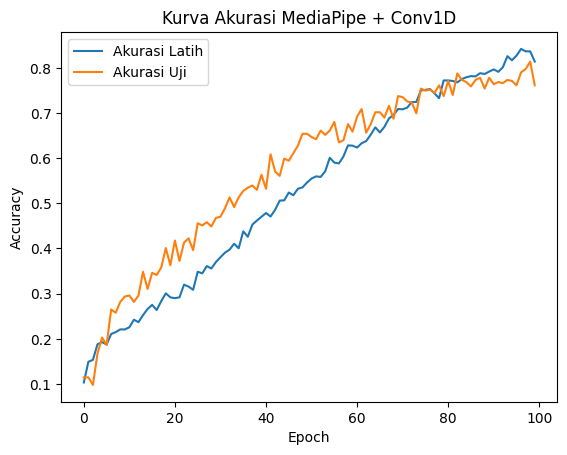

14/14 [==============================] - 1s 49ms/step - loss: 0.9613 - accuracy: 0.7613

[HASIL] Akurasi Prediksi: 76.13%


In [24]:
# EVALUASI AKURASI DAN GRAFIK
plt.plot(history.history['accuracy'], label='Akurasi Latih')
plt.plot(history.history['val_accuracy'], label='Akurasi Uji')
plt.legend()
plt.title('Kurva Akurasi MediaPipe + Conv1D')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.show()

loss, acc = model.evaluate(x_test, y_test)
print(f"\n[HASIL] Akurasi Prediksi: {acc*100:.2f}%")


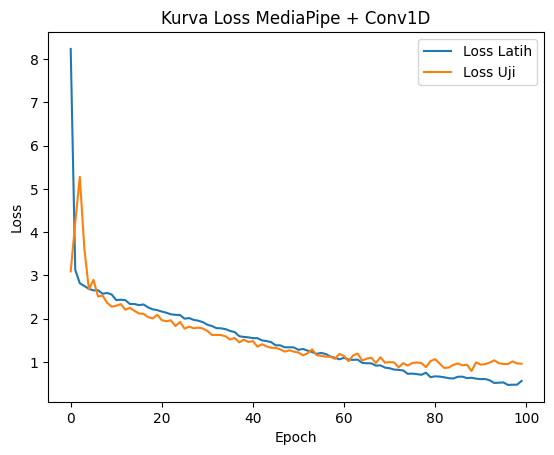

In [25]:
# Kurva Loss
plt.figure()
plt.plot(history.history['loss'], label='Loss Latih')
plt.plot(history.history['val_loss'], label='Loss Uji')
plt.legend()
plt.title('Kurva Loss MediaPipe + Conv1D')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()


14/14 [==============================] - 1s 30ms/step


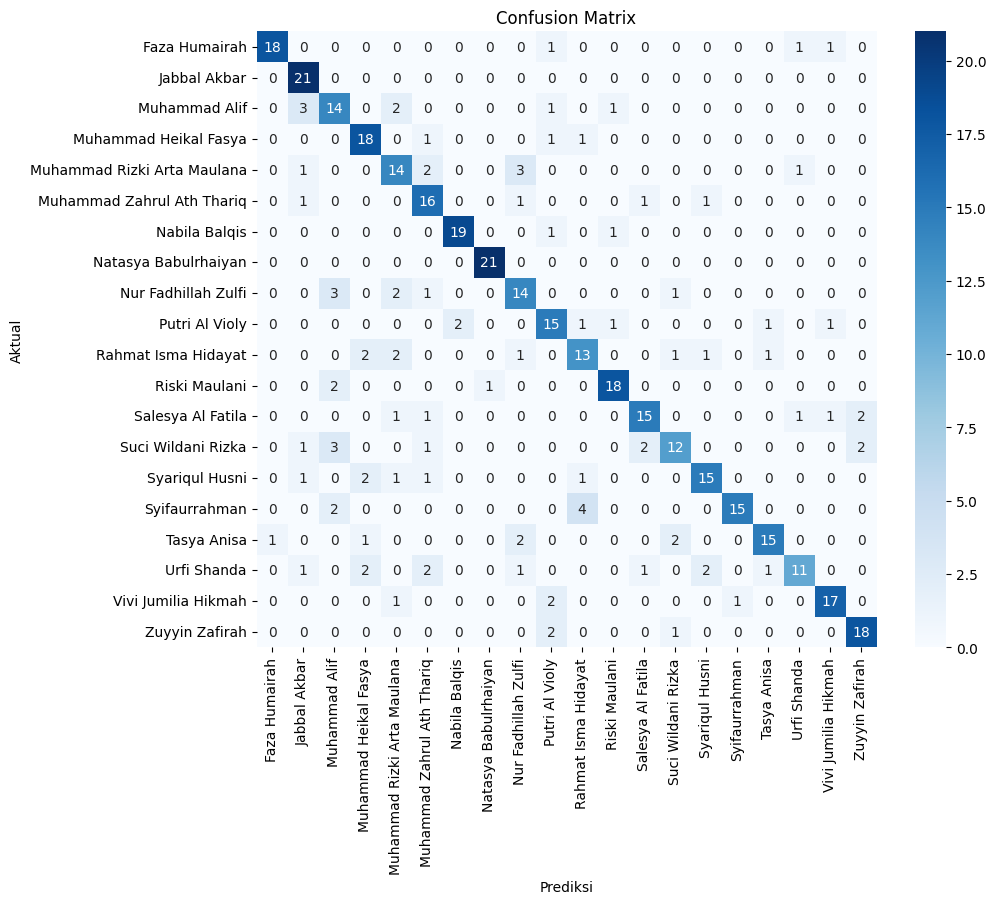

=== CLASSIFICATION REPORT ===
                             precision    recall  f1-score   support

              Faza Humairah       0.95      0.86      0.90        21
               Jabbal Akbar       0.72      1.00      0.84        21
              Muhammad Alif       0.58      0.67      0.62        21
      Muhammad Heikal Fasya       0.72      0.86      0.78        21
Muhammad Rizki Arta Maulana       0.61      0.67      0.64        21
 Muhammad Zahrul Ath Thariq       0.64      0.80      0.71        20
              Nabila Balqis       0.90      0.90      0.90        21
       Natasya Babulrhaiyan       0.95      1.00      0.98        21
        Nur Fadhillah Zulfi       0.64      0.67      0.65        21
             Putri Al Violy       0.65      0.71      0.68        21
        Rahmat Isma Hidayat       0.65      0.62      0.63        21
              Riski Maulani       0.86      0.86      0.86        21
          Salesya Al Fatila       0.79      0.71      0.75        21
   

In [26]:
# Confusion Matrix dan Classification Report
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# Ambil nama class dari label encoder
class_names = le.classes_

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.show()

# Classification Report
print("=== CLASSIFICATION REPORT ===")
print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))


In [31]:
import cv2
import numpy as np
import mediapipe as mp
import tensorflow as tf
import pickle

# ============================
# LOAD MODEL
# ============================
model = tf.keras.models.load_model("model_cnn_last.keras")

with open("label_encoder_last.pickle", "rb") as f:
    le = pickle.load(f)

mean = np.load("mean_landmark.npy")
std = np.load("std_landmark.npy")

# ============================
# THRESHOLD
# ============================
CONF_THRESHOLD = 0.80
DIFF_THRESHOLD = 0.15

# ============================
# MEDIAPIPE
# ============================
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=False,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ============================
# CAMERA
# ============================
cap = cv2.VideoCapture(0)

while True:
    ret, frame = cap.read()
    if not ret:
        break

    img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = face_mesh.process(img_rgb)

    nama = "No Face"
    confidence = 0

    if results.multi_face_landmarks:

        face_landmarks = results.multi_face_landmarks[0]

        landmarks_array = []

        for lm in face_landmarks.landmark:
            landmarks_array.append([
                lm.x,
                lm.y,
                lm.z
            ])

        landmarks_array = np.array(
            landmarks_array,
            dtype=np.float32
        )

        # ============================
        # NORMALISASI
        # ============================
        landmarks_array = (landmarks_array - mean) / std

        x_input = np.expand_dims(
            landmarks_array,
            axis=0
        )

        # ============================
        # PREDIKSI
        # ============================
        pred = model.predict(
            x_input,
            verbose=0
        )[0]

        class_idx = np.argmax(pred)
        confidence = float(pred[class_idx])

        # top-2 confidence
        sorted_pred = np.sort(pred)
        top1 = sorted_pred[-1]
        top2 = sorted_pred[-2]

        diff = top1 - top2

        # ============================
        # DEBUG TOP-3
        # ============================
        top3 = np.argsort(pred)[-3:][::-1]

        print("\n====================")
        for i in top3:
            print(
                f"{le.classes_[i]} : {pred[i]*100:.2f}%"
            )

        print(
            f"Top1={top1:.3f}  "
            f"Top2={top2:.3f}  "
            f"Diff={diff:.3f}"
        )

        # ============================
        # KEPUTUSAN
        # ============================
        if confidence >= CONF_THRESHOLD and diff >= DIFF_THRESHOLD:
            nama = le.classes_[class_idx]
        else:
            nama = "Unknown"

        # ============================
        # BOUNDING BOX
        # ============================
        h, w, _ = frame.shape

        xs = [lm.x * w for lm in face_landmarks.landmark]
        ys = [lm.y * h for lm in face_landmarks.landmark]

        x1 = int(min(xs))
        y1 = int(min(ys))
        x2 = int(max(xs))
        y2 = int(max(ys))

        cv2.rectangle(
            frame,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        text = f"{nama} ({confidence*100:.2f}%)"

        cv2.putText(
            frame,
            text,
            (x1, y1 - 10),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2
        )

    cv2.imshow(
        "MediaPipe + Conv1D Face Recognition",
        frame
    )

    key = cv2.waitKey(1)

    if key == ord('q'):
        break

cap.release()
cv2.destroyAllWindows()

d:\FaceAttend_VC\venv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '



Muhammad Alif : 78.81%
Tasya Anisa : 13.98%
Urfi Shanda : 3.23%
Top1=0.788  Top2=0.140  Diff=0.648

Faza Humairah : 60.96%
Riski Maulani : 23.19%
Urfi Shanda : 9.53%
Top1=0.610  Top2=0.232  Diff=0.378

Faza Humairah : 66.43%
Riski Maulani : 22.77%
Urfi Shanda : 6.71%
Top1=0.664  Top2=0.228  Diff=0.437

Faza Humairah : 76.48%
Riski Maulani : 16.11%
Urfi Shanda : 4.81%
Top1=0.765  Top2=0.161  Diff=0.604

Faza Humairah : 72.27%
Riski Maulani : 20.99%
Urfi Shanda : 4.51%
Top1=0.723  Top2=0.210  Diff=0.513

Faza Humairah : 72.72%
Riski Maulani : 21.76%
Urfi Shanda : 3.78%
Top1=0.727  Top2=0.218  Diff=0.510

Faza Humairah : 72.63%
Riski Maulani : 20.51%
Urfi Shanda : 4.53%
Top1=0.726  Top2=0.205  Diff=0.521

Faza Humairah : 73.87%
Riski Maulani : 12.78%
Urfi Shanda : 8.98%
Top1=0.739  Top2=0.128  Diff=0.611

Faza Humairah : 70.85%
Riski Maulani : 20.12%
Urfi Shanda : 5.87%
Top1=0.708  Top2=0.201  Diff=0.507

Faza Humairah : 67.25%
Riski Maulani : 25.15%
Urfi Shanda : 4.99%
Top1=0.672  Top2=